# IST8310 校准后飞行包：条件性离线 EKF 分析

源数据：`bags/hardware_20260924_163013_022677`；记录日期 2026-09-24。分析使用项目原生 `agi::EkfImu`，本笔记本是现有结果的只读入口，默认保留已执行图表。

## 结论速览

**能够得到条件性融合轨迹，但本次结果不足以确认定位正确或支持直接进入自主飞行。** 主方案第 1 段接受 372/375 次导航更新；第 2 段接受 413/472 次，并在末端出现连续拒绝。同源 GPS 水平残差的 P95 分别为 **0.685 m / 10.506 m**，第二段最大达到 **20.912 m**。这些是相对于已用于融合的 GPS 的一致性指标，**不是独立定位精度**。

线上原始 bag 未完成初始化；离线结果依赖短窗初态、缺失高度重建及飞行中重新给定初态。当前证据更适合定位时序、传感器一致性和模型问题。系统校时与 PID profile 解释见 [clock_and_profiles.md](clock_and_profiles.md)。

## 背景与方法

分析问题是：在明确修复时间轴、声明初态假设后，已有 IMU / GPS / IST8310 航向能否在原生 EKF 中形成一致轨迹？

### 关键假设

- 消除已测得的 **36.148773 s** 系统时钟前跳；保留约 **0.409484 s** 的真实 IMU 缺口。分两段运行，**不跨缺口积分、不跨会话插值高度**。
- 首段仅有约 2.48 s 明确未解锁 IMU。主方案用前 2 s（999 样本、实际跨度 1.998420 s）估计倾角与陀螺均值；不满足线上 3 s 初始化要求。前段 GPS 也曾超过 0.3 m/s 静止门限。
- 第二段在飞行中开始，不能静态估计倾角/零偏；沿用前段末态的倾角和偏置，以当时 GPS 给定位置、速度、航向，重置协方差。这是显式离线假设，并非有效的线上重启。
- **原始全速 GPS 高度缺失**。使用约 1 Hz 的 MSL 诊断快照，在同一会话内重建高度；线性插值使用未来样本，另以保持最近值方案检查敏感性。两者都不是完整原始数据回放。
- GPS 使用 ENU；IMU 使用机体 FLU。用户确认 IST8310 真北方向及飞控磁偏角补偿，ROS 航向修正为 **0 rad**。本次没有独立位置/航向真值。
- NIS 是按模型协方差归一化的创新一致性量，门限为 24.322。关闭门限仅用于离线敏感性检查，不构成飞行配置建议。

## 环境与可选重算

默认只读 JSON 和已保存图片；需要 Python 3、IPython/Jupyter。完整重算另需 `numpy`、`mcap`、`mcap-ros2-support`、`pyyaml`、`matplotlib` 以及已编译的 `offline_ekf`。

如需构建，请在配置好的 ROS / agilib 构建环境下手动执行 `bash build_runner.sh`；脚本默认读取仓库 `build/agi_ros2`，可用 `AGILIB_BUILD_DIR` 指定已有构建。**笔记本默认不构建。**

只有把下方 `RECOMPUTE` 改为 `True` 才重写本分析目录中的派生结果。重算使用保存的硬件参数快照；不会连接飞机或运行 ROS 控制节点。

In [1]:
from pathlib import Path
import hashlib
import json
import math
import subprocess
import sys
from IPython.display import Image, Markdown, display

RECOMPUTE = False
relative = Path("agi_ros2/analysis/hardware_flight_20260924_163013/offline_ekf")
candidates = []
for parent in [Path.cwd(), *Path.cwd().parents]:
    candidates.extend([parent, parent / relative])
HERE = next(path.resolve() for path in candidates if (path / "initialization_audit.json").is_file()
            and (path / "prepare_inputs.py").is_file())
ROOT = HERE.parents[3]
BAG = ROOT / "bags/hardware_20260924_163013_022677"
print("分析目录：", HERE)
print("默认重算：", RECOMPUTE)
print("Python：", sys.version.split()[0])

分析目录： /home/sia/agilicious_internal-main/agi_ros2/analysis/hardware_flight_20260924_163013/offline_ekf
默认重算： False
Python： 3.10.12


In [2]:
if RECOMPUTE:
    if not (HERE / "offline_ekf").is_file():
        raise FileNotFoundError("先在相应构建环境手动运行 bash build_runner.sh")
    steps = [
        ["prepare_inputs.py", str(BAG), "--output", str(HERE / "inputs"),
         "--profile", str(HERE / "inputs/hardware_snapshot.yaml")],
        ["initialization_audit.py", str(BAG), "--output", str(HERE / "initialization_audit.json")],
        ["run_analysis.py"],
        ["plot_results.py"],
        ["verify_runner.py"],
        ["review_runner.py"],
    ]
    for step in steps:
        process = subprocess.run([sys.executable, str(HERE / step[0]), *step[1:]],
                                 cwd=HERE, text=True, capture_output=True)
        if process.returncode:
            raise RuntimeError(f"{step[0]} 失败：\n{process.stdout}\n{process.stderr}")
        print(step[0], "执行成功")
else:
    print("只读现有结果；未运行构建、数据准备、滤波或图表生成命令。")

只读现有结果；未运行构建、数据准备、滤波或图表生成命令。


## 数据与来源

下面读取五份审计结果，并记录图片与参数快照的内容摘要。`input_audit.json` 汇总原始 MCAP 的读取和预处理，`initialization_audit.json` 独立核对初始化窗口。所有窗口标准差都是描述性统计，不能把飞行中的运动方差直接用于测量噪声标定。

In [3]:
paths = {
    "input": "inputs/input_audit.json",
    "results": "results/results.json",
    "initialization": "initialization_audit.json",
    "runner_review": "runner_review.json",
    "verification": "unitcases/verification.json",
}
artifacts = {name: json.loads((HERE / path).read_text()) for name, path in paths.items()}
input_audit = artifacts["input"]
results = artifacts["results"]
initialization = artifacts["initialization"]
review = artifacts["runner_review"]
verification = artifacts["verification"]
tracked = [*paths.values(), "results/trajectory.png", "results/consistency.png",
           "inputs/hardware_snapshot.yaml"]
hashes_before = {path: hashlib.sha256((HERE / path).read_bytes()).hexdigest() for path in tracked}
assert hashes_before["inputs/hardware_snapshot.yaml"] == input_audit["profile_sha256"]
assert results["profile_sha256"] == input_audit["profile_sha256"]

def table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
    lines.extend("| " + " | ".join(str(value) for value in row) + " |" for row in rows)
    display(Markdown("\n".join(lines)))

table(["证据", "记录值"], [
    ["bag", input_audit["source_bag"]],
    ["全包检查条数", input_audit["messages_checked"]],
    ["IMU / GPS / 高度快照", f"{input_audit['imu_samples']} / {input_audit['gps_observations']} / {input_audit['height_snapshot_count']}"],
    ["时钟前跳（s）", f"{input_audit['clock_step_seconds']:.9f}"],
    ["修正时间后最大 IMU 缺口（s）", f"{input_audit['imu_max_gap_seconds']:.9f}"],
    ["线性重建后导航观测数", input_audit["variants"]["linear"]["observations"]],
    ["原生滤波器", results["filter"]],
])
table(["产物", "SHA-256 前 16 位"], [[path, digest[:16]] for path, digest in hashes_before.items()])

| 证据 | 记录值 |
| --- | --- |
| bag | hardware_20260924_163013_022677 |
| 全包检查条数 | 154311 |
| IMU / GPS / 高度快照 | 45357 / 883 / 91 |
| 时钟前跳（s） | 36.148772983 |
| 修正时间后最大 IMU 缺口（s） | 0.409483520 |
| 线性重建后导航观测数 | 867 |
| 原生滤波器 | production agi::EkfImu from rebuilt libagilib |

| 产物 | SHA-256 前 16 位 |
| --- | --- |
| inputs/input_audit.json | a6c483ab3b1f9788 |
| results/results.json | 53d6192db33e8165 |
| initialization_audit.json | 9759fcdafd759b12 |
| runner_review.json | 43046b1468ca68bd |
| unitcases/verification.json | 9fe0174bc99b2be8 |
| results/trajectory.png | dc2308ce67e3546e |
| results/consistency.png | f165480fb07df575 |
| inputs/hardware_snapshot.yaml | 06448001681fb316 |

### 初始与末端静止检查

下表使用 bag 接收时间选择窗口，跨度由 IMU header 计算；因此初始化审计的 bag 相对秒与后续轨迹的“首个 IMU 起算、消除时钟跳变后的秒数”不是同一零点。初段 1 s / 2 s 结果与主分析预处理进行独立核对。

In [4]:
rows = []
for label, key in [("首 1 s", "initial_first_1s"), ("首 2 s", "initial_first_2s"),
                   ("明确未解锁首段", "initial_entire_known_disarmed"),
                   ("末尾未解锁", "last_disarmed"), ("末 2 s", "last_2s"),
                   ("会话 2 首 2 s", "post_clock_first_2s")]:
    window = initialization["windows"][key]
    rows.append([label, window["imu_samples"], f"{window['imu_header_span_s']:.6f}",
                 f"{window['accel_mean_norm_m_s2']:.6f}",
                 f"{max(window['accel_stddev_m_s2']):.4f}",
                 f"{window['speed_m_s']['max']:.4f}",
                 "通过" if window["std_bias_gravity_thresholds_pass"] else "未通过"])
table(["窗口", "IMU 样本", "跨度 s", "加速度均值模长 m/s²", "最大轴标准差 m/s²", "GPS 最大速度 m/s", "IMU 门限"], rows)
for duration, key in [("1.0", "initial_first_1s"), ("2.0", "initial_first_2s")]:
    source = input_audit["seeds"][duration]
    audit = initialization["windows"][key]
    assert source["samples"] == audit["imu_samples"]
    for left, right in [(source["acceleration_mean"], audit["accel_mean_m_s2"]),
                        (source["gyro_mean"], audit["gyro_mean_rad_s"])]:
        assert all(math.isclose(a, b, abs_tol=1e-12) for a, b in zip(left, right))
print("首 1 s / 2 s 初始化均值与独立审计一致。")

| 窗口 | IMU 样本 | 跨度 s | 加速度均值模长 m/s² | 最大轴标准差 m/s² | GPS 最大速度 m/s | IMU 门限 |
| --- | --- | --- | --- | --- | --- | --- |
| 首 1 s | 500 | 0.999671 | 9.807851 | 0.0206 | 0.3550 | 通过 |
| 首 2 s | 999 | 1.998420 | 9.801100 | 0.0204 | 0.3550 | 通过 |
| 明确未解锁首段 | 1241 | 2.483300 | 9.796561 | 0.0220 | 0.3550 | 通过 |
| 末尾未解锁 | 1500 | 3.002881 | 9.265491 | 2.3268 | 0.2888 | 未通过 |
| 末 2 s | 999 | 1.999095 | 9.263736 | 0.0193 | 0.2476 | 未通过 |
| 会话 2 首 2 s | 1000 | 2.000735 | 9.244246 | 2.3174 | 0.4847 | 未通过 |

首 1 s / 2 s 初始化均值与独立审计一致。


初段 IMU 倾角/零偏统计可用于探索性初态，但时间不足，且 GPS 曾超过 0.3 m/s。会话 2 首部加速度/角速度变化大，不能估计静态零偏。

**末 2 s 已低振动，但加速度均值模长约 9.264 m/s²，与项目重力 9.8066 相差约 0.543 m/s²。** 这超过当前 0.5 门限，也是初末基线不一致的待查证据；本分析没有确定其原因。

## 结果

主方案为 `linear_2s`：两秒短窗初态、约 1 Hz 高度快照线性重建、NIS 门限 24.322。统计覆盖该段全部已评估导航更新，包括接受和拒绝的更新；“后验减 GPS”始终是同源输入残差。

In [5]:
baseline = next(case for case in results["cases"] if case["name"] == "linear_2s")
table(["分段", "接受 / 总更新", "拒绝", "水平残差 P95 m", "水平残差最大 m", "垂直残差 P95 m", "速度残差 P95 m/s", "NIS P95"], [
    [segment["epoch"] + 1, f"{segment['accepted']} / {segment['updates']}", segment["rejected"],
     f"{segment['horizontal_input_residual_m']['p95']:.3f}",
     f"{segment['horizontal_input_residual_m']['maximum']:.3f}",
     f"{segment['vertical_input_residual_m']['p95']:.3f}",
     f"{segment['velocity_input_residual_m_s']['p95']:.3f}", f"{segment['nis']['p95']:.3f}"]
    for segment in baseline["segments"]
])
table(["分段", "显式给定初态的修正时间 s", "位置/速度来源"], [
    [seed["epoch"] + 1, f"{seed['time_s']:.9f}", ("首个可用 GPS；静止短窗倾角/偏置" if seed["epoch"] == 0 else "当前 GPS；沿用前段倾角/偏置")]
    for seed in baseline["seeds"]
])

| 分段 | 接受 / 总更新 | 拒绝 | 水平残差 P95 m | 水平残差最大 m | 垂直残差 P95 m | 速度残差 P95 m/s | NIS P95 |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | 372 / 375 | 3 | 0.685 | 0.866 | 2.602 | 1.756 | 17.702 |
| 2 | 413 / 472 | 59 | 10.506 | 20.912 | 4.548 | 3.538 | 192.552 |

| 分段 | 显式给定初态的修正时间 s | 位置/速度来源 |
| --- | --- | --- |
| 1 | 2.057287168 | 首个可用 GPS；静止短窗倾角/偏置 |
| 2 | 42.360858368 | 当前 GPS；沿用前段倾角/偏置 |

### 轨迹

蓝线是保留 NIS 门限的 EKF；灰色是参与融合的 GPS 输入；橙色是关闭门限的诊断对照。竖向图的灰色高度经过重建，不能作为独立高度真值。两个分段分别绘制，灰带表示真实 IMU 缺口。

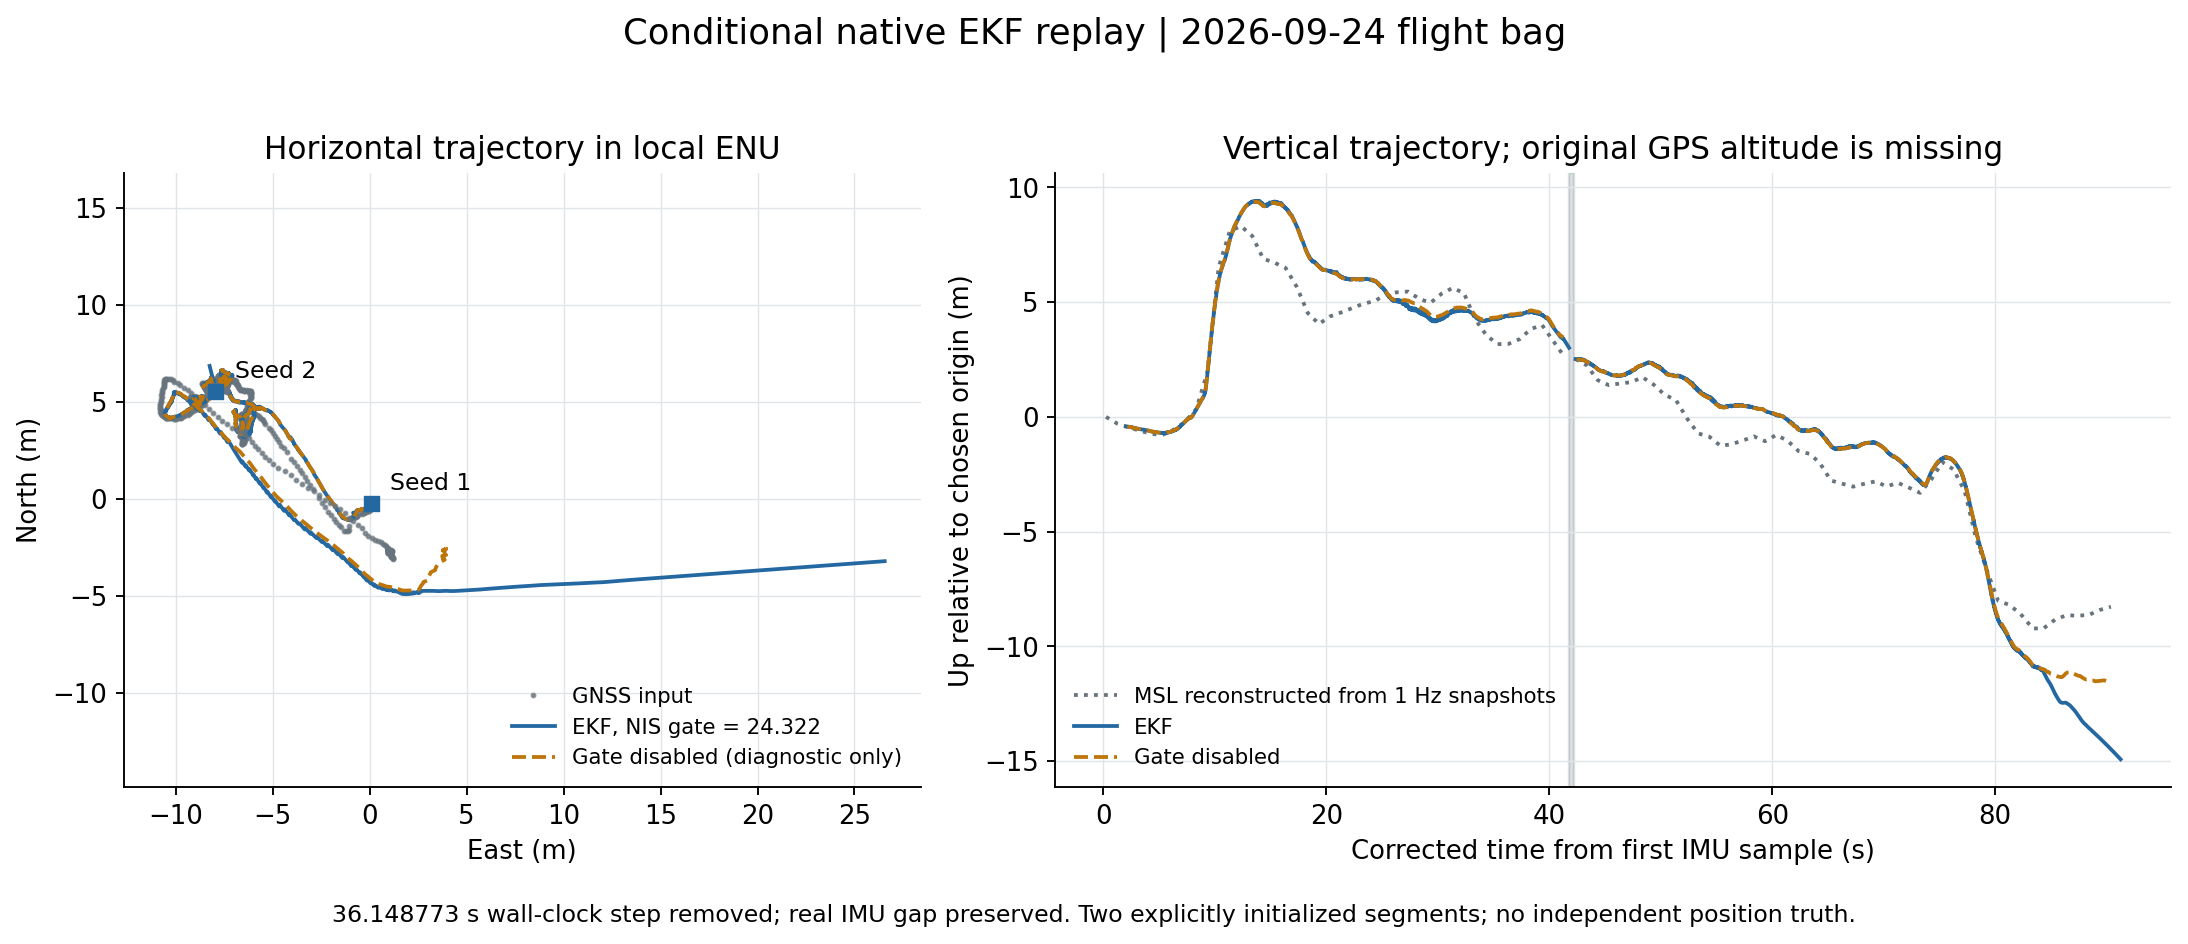

In [6]:
display(Image(filename=str(HERE / "results/trajectory.png"), width=1100))

后半程蓝线末端明显偏离 GPS 输入；图中下降高度也是相对所选原点的结果，不能据此判断真实离地高度。关闭门限后轨迹更贴近输入，只说明融合行为变化，并未证明哪条轨迹更准确。

### 创新与拒绝历史

下图把水平输入残差、速度输入残差和 NIS 按同一修正时间轴排列；红叉为拒绝更新。NIS 是 7 维联合量，包含相关协方差，不能把单轴创新大小当作精确原因分解。

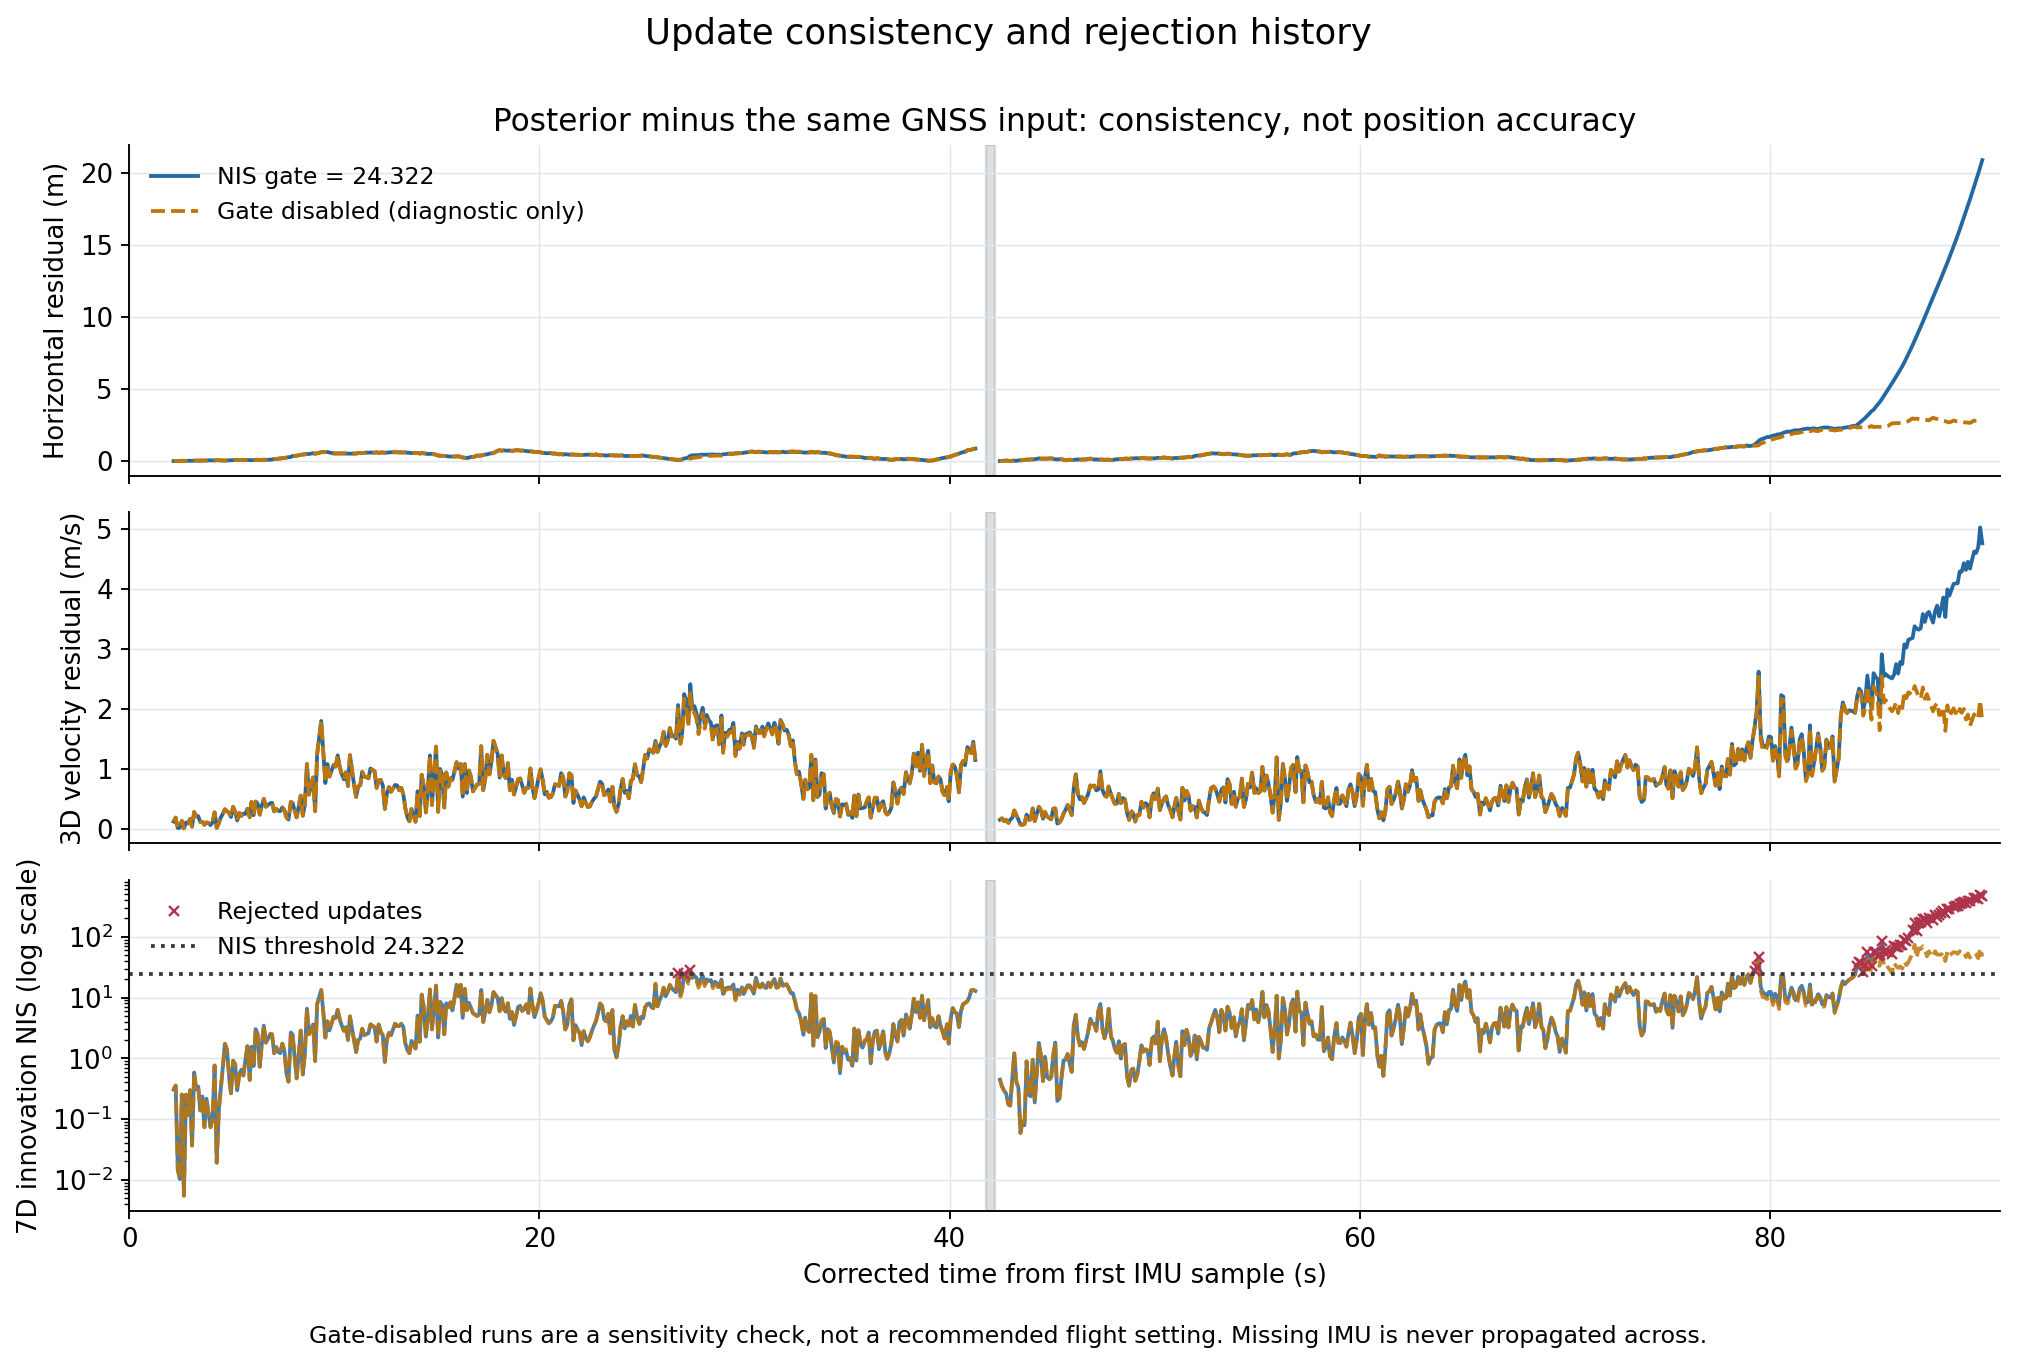

In [7]:
display(Image(filename=str(HERE / "results/consistency.png"), width=1100))

In [8]:
table(["连续拒绝开始 s", "结束 s", "次数", "最大 NIS"], [
    [f"{cluster['start_s']:.6f}", f"{cluster['end_s']:.6f}", cluster["count"],
     f"{cluster['maximum_nis']:.3f}"] for cluster in review["rejection_clusters"]
])
terminal = review["rejection_clusters"][-1]
print(f"末端连续拒绝：{terminal['count']} 次，{terminal['start_s']:.6f}–{terminal['end_s']:.6f} s。")

| 连续拒绝开始 s | 结束 s | 次数 | 最大 NIS |
| --- | --- | --- | --- |
| 26.759100 | 26.759100 | 1 | 24.894 |
| 27.057586 | 27.057586 | 1 | 24.458 |
| 27.358011 | 27.358011 | 1 | 28.621 |
| 79.263186 | 79.461635 | 3 | 47.177 |
| 84.266281 | 90.370253 | 56 | 490.142 |

末端连续拒绝：56 次，84.266281–90.370253 s。


末端连续拒绝开始于约 **84.266 s**，距重新给定初态已有约 42 s，不是在时钟会话切换的瞬间发生。拒绝开始时位置/速度创新已经偏大，随后失去导航修正，偏离继续扩大。该证据不能单独证明 GPS、IMU 或哪一个参数有错；传感器时延、加速度偏置/振动、初态及高度重建/噪声模型仍需进一步排查。

### 离线敏感性对照

比较高度保持最近值、首 1 s 初态和关闭创新门限。最后一项只能帮助理解拒绝更新的影响；不应将其直接应用于实机。

In [9]:
table(["方案", "分段", "接受 / 总数", "水平残差 P95 m", "水平最大残差 m"], [
    [case["name"], segment["epoch"] + 1, f"{segment['accepted']} / {segment['updates']}",
     f"{segment['horizontal_input_residual_m']['p95']:.3f}",
     f"{segment['horizontal_input_residual_m']['maximum']:.3f}"]
    for case in results["cases"] for segment in case["segments"]
])

| 方案 | 分段 | 接受 / 总数 | 水平残差 P95 m | 水平最大残差 m |
| --- | --- | --- | --- | --- |
| linear_2s | 1 | 372 / 375 | 0.685 | 0.866 |
| linear_2s | 2 | 413 / 472 | 10.506 | 20.912 |
| hold_2s | 1 | 372 / 375 | 0.684 | 0.873 |
| hold_2s | 2 | 413 / 472 | 10.503 | 20.911 |
| linear_1s | 1 | 382 / 385 | 0.740 | 0.893 |
| linear_1s | 2 | 413 / 472 | 10.559 | 21.014 |
| linear_2s_ungated | 1 | 375 / 375 | 0.685 | 0.870 |
| linear_2s_ungated | 2 | 472 / 472 | 2.762 | 3.016 |

## 校验与后续行动

合成算例检查静止重力补偿、创新门限、缺口终止、显式重新初始化，以及延迟导航的缓存回放；真实 bag 的独立检查将 GPS 送达延迟 20 ms，并比较状态、协方差、NIS 和接受/拒绝决策。它们检查离线 runner 的实现行为，**不会证明传感器输出或真实定位精度正确**。

In [10]:
assert verification["passed"] is True
assert all(item["statuses_match"] for item in review["real_bag_delayed_delivery"])
checks = [["合成算例", "通过（读取已保存 verification.json）"],
          ["静止高度最大漂移 m", verification["gated"]["max_stationary_vertical_drift_m"]],
          ["合成即时/延迟更新最大差值", max(verification["immediate_vs_delayed"]["max_absolute_differences"].values())]]
for item in review["real_bag_delayed_delivery"]:
    checks.append([f"真实 bag 第 {item['epoch'] + 1} 段延迟 20 ms 最大字段差值",
                   f"{max(item['max_absolute_differences'].values()):.3e}"])
table(["检查", "结果"], checks)
hashes_after = {path: hashlib.sha256((HERE / path).read_bytes()).hexdigest() for path in tracked}
assert hashes_after == hashes_before, "读取期间派生结果发生变化，请重执行笔记本。"
print("默认分析单元执行完成；读取期间源审计、结果、参数快照及两张图片均未发生变化。")

| 检查 | 结果 |
| --- | --- |
| 合成算例 | 通过（读取已保存 verification.json） |
| 静止高度最大漂移 m | 0.0 |
| 合成即时/延迟更新最大差值 | 0.0 |
| 真实 bag 第 1 段延迟 20 ms 最大字段差值 | 0.000e+00 |
| 真实 bag 第 2 段延迟 20 ms 最大字段差值 | 1.321e-07 |

默认分析单元执行完成；读取期间源审计、结果、参数快照及两张图片均未发生变化。


### 当前能采取的行动

这份结果已经指出需要复查的末端一致性问题。下一轮先取得时间稳定、未解锁静止不少于 60 s 的记录，验证在线原点/融合初始化；保存完整 GPS 高度、速度、接收机精度、IMU 与原始飞控状态，再核对初末加速度基线。若要回答“定位是否正确”，需同时记录独立参考，例如 RTK 或已测量位置点；使用参与融合的 GPS 自身不能完成这一验证。

记录与方法入口：[input_audit.json](inputs/input_audit.json)、[results.json](results/results.json)、[initialization_audit.py](initialization_audit.py)、[runner_README.md](runner_README.md)、[plot_results.py](plot_results.py)。图表使用可编辑脚本生成，已内嵌在本笔记本输出中，打开时无需重新滤波。